In [9]:
import pickle
# import coup
from coup import COUP

%reload_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
from dotenv import load_dotenv
import os
from ConfigSpace.read_and_write import pcs_new

from solver import Solver

from utils import u_geometric
import wandb

from utils import parse_u, u_to_str, ensure_directory

load_dotenv("../.env")

True

In [13]:
state_savepath = f"../storage_alice/coup_mipverify/training_data.p"
state = pickle.load(open(state_savepath, 'rb'))

solver = Solver("../aclib2/target_algorithms/sat/spear/MipVerify", "./aclib2/instances/mip/data/SDPdMLPa-MIPVerify", seed=98)

# u_str = u_to_str(args.u)
# u_fn, u_params = u_geometric k0=250 k1=9600

with open(os.getenv("TRAIN_INSTANCE_FILE")) as filehandle:
    instances = [line.rstrip() for line in filehandle]
# breakpoint()
instances.sort() # sort for reproducibility
np.random.seed(98)
np.random.shuffle(instances)

coup = COUP(None, instances, lambda t: u_geometric(t, k0=250, k1=9600), delta=.01, n0=10, k0=500, state=state, savepath=state_savepath, usemodel=False, usehoeffding=False, useucb=False)

print(coup.U_hat)


[0.84892727 0.64643003 0.46889112 0.48287641 0.72027022 0.47484064
 0.55947178 0.53447601 0.71491727 0.81992703]


In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
import math
from matplotlib import pyplot as plt

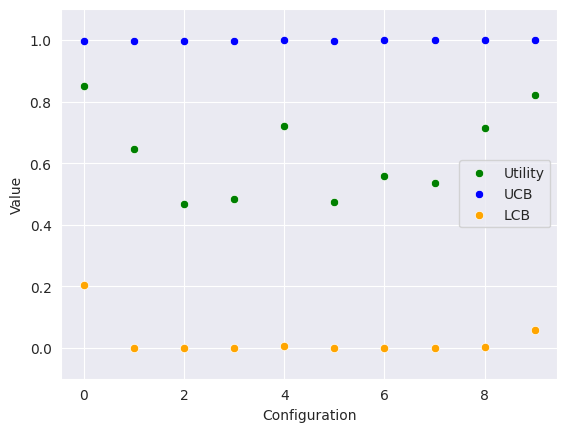

In [16]:
# sns.boxplot(x=[i for i in range(len(glob.glob(file_loc, recursive=False)))], y=utils, whis=list(pairs))
n_utils = len(coup.U_hat)

sns.scatterplot(x=[i for i in range(n_utils)], y=coup.U_hat, color="green", label="Utility")
sns.scatterplot(x=[i for i in range(n_utils)], y=coup.UCB, color="blue", label="UCB")
sns.scatterplot(x=[i for i in range(n_utils)], y=coup.LCB, color="orange", label="LCB")
plt.ylim(-0.1, 1.1)
plt.xlabel("Configuration")
plt.ylabel("Value")
plt.legend()

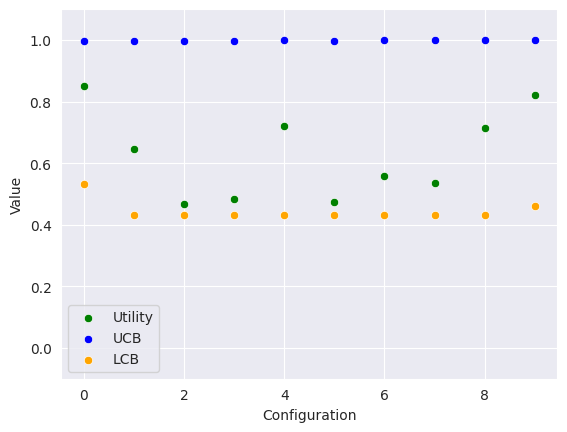

In [17]:
n_utils = len(coup.U_hat)

sns.scatterplot(x=[i for i in range(n_utils)], y=coup.U_hat, color="green", label="Utility")
sns.scatterplot(x=[i for i in range(n_utils)], y=coup.U_hat_ucb, color="blue", label="UCB")
sns.scatterplot(x=[i for i in range(n_utils)], y=coup.U_hat_lcb, color="orange", label="LCB")
plt.ylim(-0.1, 1.1)
plt.xlabel("Configuration")
plt.ylabel("Value")
plt.legend()

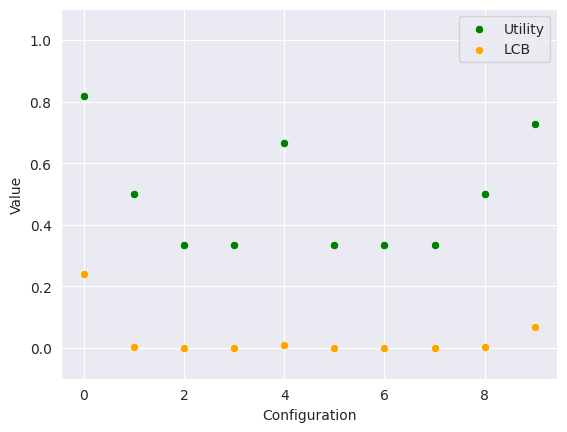

In [18]:
n_utils = len(coup.U_hat)

sns.scatterplot(x=[i for i in range(n_utils)], y=coup.F_hat, color="green", label="Utility")
# sns.scatterplot(x=[i for i in range(n_utils)], y=coup.UCB, color="blue", label="UCB")
sns.scatterplot(x=[i for i in range(n_utils)], y=coup.F_hat_lcb, color="orange", label="LCB")
plt.ylim(-0.1, 1.1)
plt.xlabel("Configuration")
plt.ylabel("Value")
plt.legend()